In [20]:
import xpress as xp
from xpress import constants   # needed for solver status constants

# -------------------------------------------------------------------
# User-defined parameters (adjust as needed)
# -------------------------------------------------------------------
num_gateway   = 8      # total number of gateway courses (must be Cg * |S| = 4*2)
num_optional  = 4      # total number of optional courses (must be Co * |S| = 2*2)
num_days      = 5      # e.g., Monday to Friday
num_hours     = 9      # e.g., 9 am – 5 pm

# Teaching requirements
RgL = 3   # lectures per gateway course
RgW = 1   # weekly workshops per gateway course
RgF = 1   # fortnightly workshops per gateway course
RoL = 3   # lectures per optional course
RoW = 1   # weekly workshops per optional course

# Courses per semester
Cg = 4    # gateway courses per semester
Co = 2    # optional courses per semester

# -------------------------------------------------------------------
# Sets (using 0‑based indices for programming convenience)
# -------------------------------------------------------------------
G = range(num_gateway)          # gateway courses
O = range(num_optional)         # optional courses
S = [1, 2]                      # semesters
D = range(num_days)             # teaching days
H = range(num_hours)            # teaching hours
W = [1, 2]                      # week parity (1 = odd, 2 = even)
for i in H:
    print(i)

0
1
2
3
4
5
6
7
8


In [21]:

# -------------------------------------------------------------------
# Create the Xpress problem
# -------------------------------------------------------------------
m = xp.problem("timetabling")

# -------------------------------------------------------------------
# Decision variables (all binary)
# -------------------------------------------------------------------
xL = {(g, d, h, s): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S}
xW = {(g, d, h, s): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S}
xF = {(g, d, h, s, w): xp.var(vartype=xp.binary)
      for g in G for d in D for h in H for s in S for w in W}
yL = {(o, d, h, s): xp.var(vartype=xp.binary)
      for o in O for d in D for h in H for s in S}
yW = {(o, d, h, s): xp.var(vartype=xp.binary)
      for o in O for d in D for h in H for s in S}
z  = {(g, s): xp.var(vartype=xp.binary) for g in G for s in S}
w  = {(o, s): xp.var(vartype=xp.binary) for o in O for s in S}

# Add all variables to the model
# Collect all variables into a single flat list
all_vars = (list(xL.values()) + list(xW.values()) + list(xF.values()) +
            list(yL.values()) + list(yW.values()) + list(z.values()) + list(w.values()))

# Add all variables to the model at once
m.addVariable(all_vars)
# -------------------------------------------------------------------
# Constraints
# -------------------------------------------------------------------

# 1. Each course runs in exactly one semester
for g in G:
    m.addConstraint(xp.Sum(z[g, s] for s in S) == 1)
for o in O:
    m.addConstraint(xp.Sum(w[o, s] for s in S) == 1)

# 2. Exactly Cg gateway courses and Co optional courses per semester
for s in S:
    m.addConstraint(xp.Sum(z[g, s] for g in G) == Cg)
    m.addConstraint(xp.Sum(w[o, s] for o in O) == Co)

# 3. Correct number of weekly teaching events per course per semester
for g in G:
    for s in S:
        m.addConstraint(xp.Sum(xL[g, d, h, s] for d in D for h in H) == RgL * z[g, s])
        m.addConstraint(xp.Sum(xW[g, d, h, s] for d in D for h in H) == RgW * z[g, s])
for o in O:
    for s in S:
        m.addConstraint(xp.Sum(yL[o, d, h, s] for d in D for h in H) == RoL * w[o, s])
        m.addConstraint(xp.Sum(yW[o, d, h, s] for d in D for h in H) == RoW * w[o, s])

# 4. Each gateway course has exactly one fortnightly workshop
for g in G:
    m.addConstraint(xp.Sum(xF[g, d, h, s, w_par]
                           for d in D for h in H for s in S for w_par in W) == 1)

# 5. A course cannot have more than one event in the same time slot
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] + xW[g, d, h, s] +
                                xp.Sum(xF[g, d, h, s, w_par] for w_par in W) <= 1)
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] + yW[o, d, h, s] <= 1)

# 6. No clashes for students in any week (for each (d,h,s,w) at most one event)
for d in D:
    for h in H:
        for s in S:
            for w_par in W:
                m.addConstraint(
                    xp.Sum(xL[g, d, h, s] for g in G) +
                    xp.Sum(xW[g, d, h, s] for g in G) +
                    xp.Sum(yL[o, d, h, s] for o in O) +
                    xp.Sum(yW[o, d, h, s] for o in O) +
                    xp.Sum(xF[g, d, h, s, w_par] for g in G) <= 1
                )

# 7. Events can only occur in the semester the course is assigned to
for g in G:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(xL[g, d, h, s] <= z[g, s])
                m.addConstraint(xW[g, d, h, s] <= z[g, s])
                for w_par in W:
                    m.addConstraint(xF[g, d, h, s, w_par] <= z[g, s])
for o in O:
    for d in D:
        for h in H:
            for s in S:
                m.addConstraint(yL[o, d, h, s] <= w[o, s])
                m.addConstraint(yW[o, d, h, s] <= w[o, s])

# -------------------------------------------------------------------
# Objective: feasibility problem – no explicit objective is needed.
# Xpress will search for any feasible solution.
# -------------------------------------------------------------------

# Solve the problem
m.solve()
status = m.getProbStatusString().lower()
# -------------------------------------------------------------------
# Output the result
# -------------------------------------------------------------------
if 'optimal' in status or 'feasible' in status:
    print("A feasible timetable has been found!")
    # (Optional) print a few assignments to verify
    for g in G:
        for s in S:
            if m.getSolution(z[g, s]) > 0.5:
                print(f"Gateway course {g} runs in semester {s}")
    for o in O:
        for s in S:
            if m.getSolution(w[o, s]) > 0.5:
                print(f"Optional course {o} runs in semester {s}")
else:
    print("No feasible solution exists. Check the parameters or constraints.")

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:9: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xL = {(g, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:11: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xW = {(g, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:13: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xF = {(g, d, h, s, w): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:15: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  yL = {(o, d, h, s): xp.var(vartype=xp.binary)
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:17: DeprecationWarning: Deprecated in Xpress

FICO Xpress v9.7.0, Hyper, solve started 20:41:07, Mar 22, 2026
Heap usage: 2770KB (peak 2770KB, 281KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
      4932 rows         3624 cols        20256 elements      3624 entities
Presolved problem has:
      1318 rows         3612 cols        14100 elements      3612 entities
Presolve finished in 0 seconds
Heap usage: 5965KB (peak 7066KB, 281KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  3.00e+00] / [ 5.00e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [      0.0,       0.0] / [      0.0,       0.0]
Autoscaling applied standard scaling

Symmetric problem: generators: 93, support set: 3612
 Number of orbits: 12, largest orbit: 720
 

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\827446342.py:108: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.solvestatus and problem.attributes.solstatus instead
  status = m.getProbStatusString().lower()


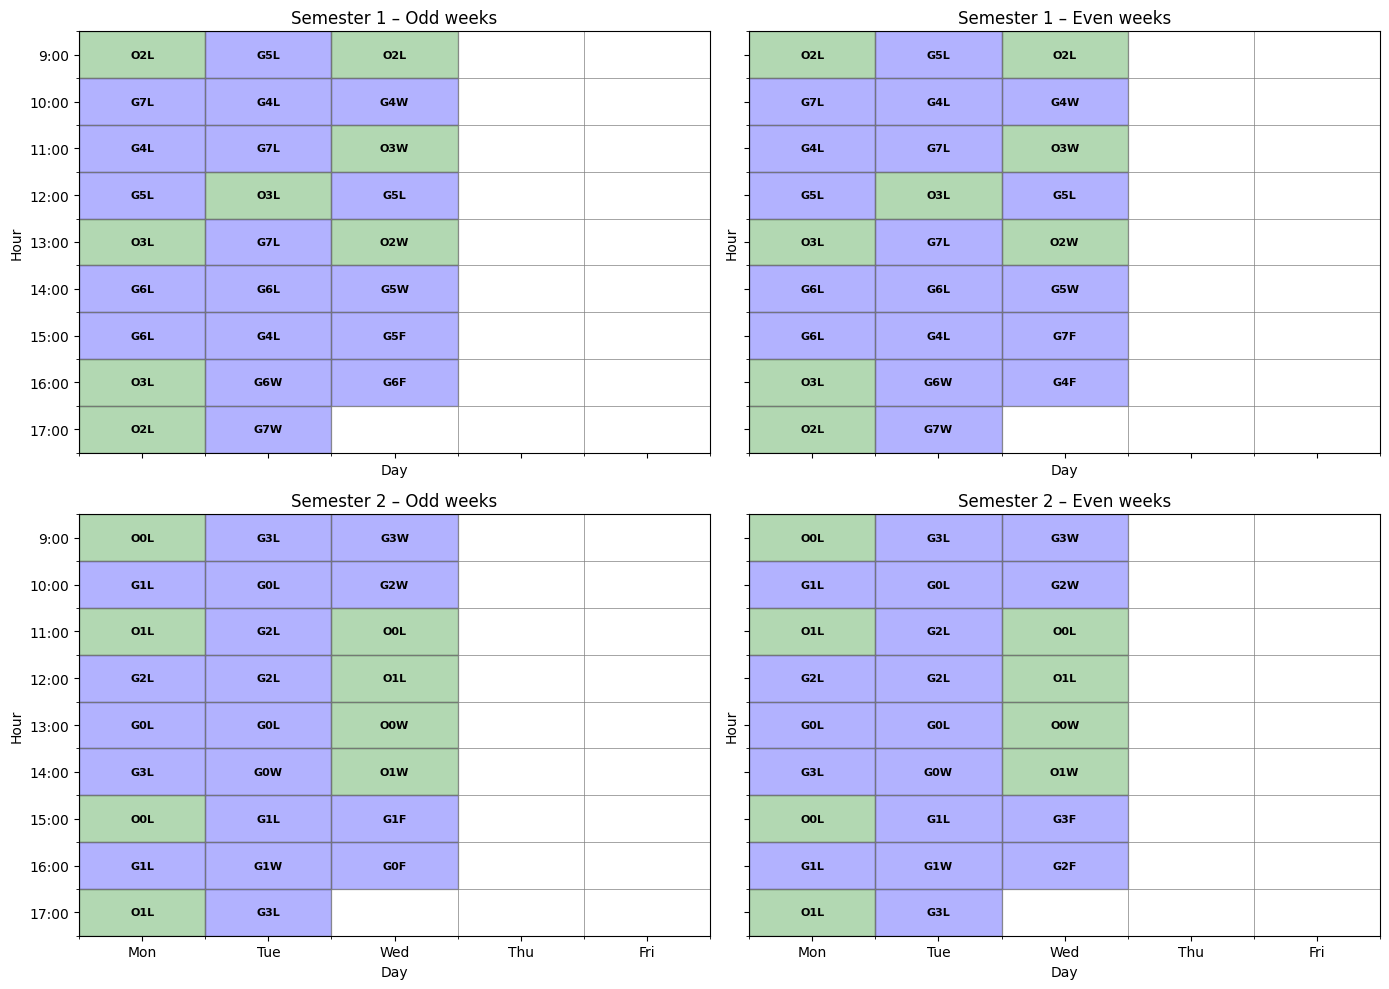

In [22]:
import matplotlib.pyplot as plt
import numpy as np
xL_sol = {k: m.getSolution(v) for k, v in xL.items()}
xW_sol = {k: m.getSolution(v) for k, v in xW.items()}
xF_sol = {k: m.getSolution(v) for k, v in xF.items()}
yL_sol = {k: m.getSolution(v) for k, v in yL.items()}
yW_sol = {k: m.getSolution(v) for k, v in yW.items()}
z_sol  = {k: m.getSolution(v) for k, v in z.items()}
w_sol  = {k: m.getSolution(v) for k, v in w.items()}
    # -------------------------------------------------------------------
    # Visualisation function
    # -------------------------------------------------------------------
def plot_timetable():
        # Create a 2x2 grid: rows = semesters, cols = week parity
        fig, axes = plt.subplots(len(S), len(W), figsize=(14, 10), sharex=True, sharey=True)
        if len(S) == 1 and len(W) == 1:
            axes = np.array([[axes]])
        elif len(S) == 1 or len(W) == 1:
            axes = axes.reshape(len(S), len(W))
        
        day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'] if num_days == 5 else [f'D{d}' for d in D]
        hour_labels = [f'{9+h}:00' for h in H]  # assuming start at 9am

        for i_s, s in enumerate(S):
            for i_w, w_par in enumerate(W):
                ax = axes[i_s, i_w]
                ax.set_title(f'Semester {s} – {"Odd" if w_par==1 else "Even"} weeks')
                ax.set_xlabel('Day')
                ax.set_ylabel('Hour')
                ax.set_xticks(np.arange(len(D)))
                ax.set_xticklabels(day_labels)
                ax.set_yticks(np.arange(len(H)))
                ax.set_yticklabels(hour_labels)
                ax.set_xlim(-0.5, len(D)-0.5)
                ax.set_ylim(-0.5, len(H)-0.5)
                ax.invert_yaxis()  # so hour 0 (9am) is at top

                # Draw grid lines
                ax.set_xticks(np.arange(-0.5, len(D), 1), minor=True)
                ax.set_yticks(np.arange(-0.5, len(H), 1), minor=True)
                ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

                # Scan all time slots
                for d in D:
                    for h in H:
                        # Collect all events at (d,h,s,w_par)
                        labels = []
                        colors = []
                        # Gateway lectures & weekly workshops (they occur in both weeks)
                        for g in G:
                            if xL_sol.get((g,d,h,s), 0) > 0.5:
                                labels.append(f'G{g}L')
                                colors.append('blue')
                            if xW_sol.get((g,d,h,s), 0) > 0.5:
                                labels.append(f'G{g}W')
                                colors.append('blue')
                            # Fortnightly workshop (depends on w_par)
                            if xF_sol.get((g,d,h,s,w_par), 0) > 0.5:
                                labels.append(f'G{g}F')
                                colors.append('blue')
                        # Optional courses
                        for o in O:
                            if yL_sol.get((o,d,h,s), 0) > 0.5:
                                labels.append(f'O{o}L')
                                colors.append('green')
                            if yW_sol.get((o,d,h,s), 0) > 0.5:
                                labels.append(f'O{o}W')
                                colors.append('green')

                        # If there is an event, draw a coloured rectangle with label
                        if labels:
                            # Combine multiple events (should not happen due to constraint)
                            text = '\n'.join(labels)
                            # Use the color of the first event (all same color if same course type)
                            color = colors[0] if colors else 'gray'
                            rect = plt.Rectangle((d-0.5, h-0.5), 1, 1,
                                                 facecolor=color, alpha=0.3, edgecolor='black')
                            ax.add_patch(rect)
                            ax.text(d, h, text, ha='center', va='center',
                                    fontsize=8, weight='bold')

        plt.tight_layout()
        plt.show()

    # Call the plotting function
plot_timetable()

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:56: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xL = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:57: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xW = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:58: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xF = {(g, d, h, s, w): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S for w in W}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:59: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  yL = 

FICO Xpress v9.7.0, Hyper, solve started 20:57:54, Mar 22, 2026
Heap usage: 5734KB (peak 5734KB, 1419KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
      9692 rows         5944 cols        63336 elements      5804 entities
Presolved problem has:
      5888 rows         5752 cols        47450 elements      5552 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 9774KB (peak 14MB, 1419KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  9.00e+00] / [ 1.25e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [ 7.18e-04,  3.73e-02] / [ 7.18e-04,  3.73e-02]
Autoscaling applied standard scaling

Symmetric problem: generators: 14, support set: 5664
 Number of orbits: 

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:281: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.solvestatus and problem.attributes.solstatus instead
  status = m.getProbStatusString().lower()
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:285: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.objval instead
  print(f"Objective value: {m.getObjVal():.2f}")


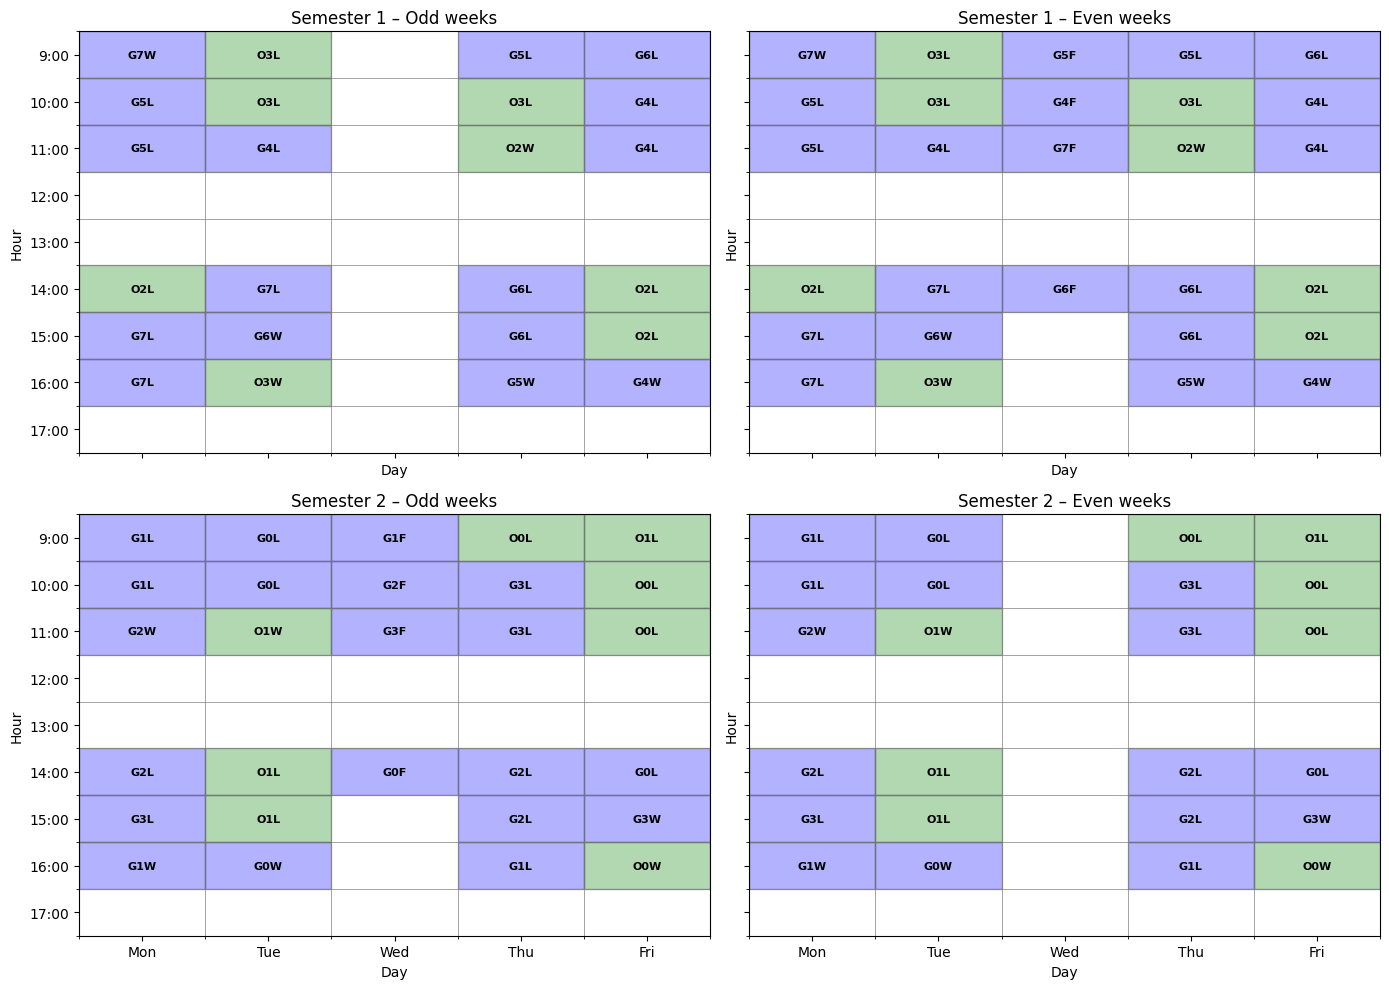

In [26]:
import xpress as xp
from xpress import constants
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# User-defined parameters (adjust as needed)
# -------------------------------------------------------------------
num_gateway = 8
num_optional = 4
num_days = 5
num_hours = 9  # hours 0..8 correspond to 9am..5pm

RgL = 3
RgW = 1
RgF = 1
RoL = 3
RoW = 1
Cg = 4
Co = 2

# Soft constraint weights (from regression)
lambda_late     = 0.344249   # after 5pm
lambda_lunch    = 0.112523   # lunch time
lambda_isolated = 0.057430   # isolated class
lambda_days     = 0.133207   # number of days
lambda_wed      = 0.028978     # Wednesday after 1pm (set your own if needed)

# Normalisation constants (maximum possible values of each raw count)
N_late  = len(S) * len(D) * len(W)          # 2 * 5 * 2 = 20
N_lunch = len(S) * len(D) * 2 * len(W)      # 2 * 5 * 2 * 2 = 40
N_isol  = len(S) * len(D) * len(W) * 4      # 2 * 5 * 2 * 4 = 80
N_days  = len(S) * len(D) * len(W)          # 20
N_wed   = len(S) * 5 * len(W)               # 2 * 5 * 2 = 20

# -------------------------------------------------------------------
# Sets
# -------------------------------------------------------------------
G = range(num_gateway)
O = range(num_optional)
S = [1, 2]
D = range(num_days)
H = range(num_hours)
W = [1, 2]  # week parity (1 = odd, 2 = even)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
wed_idx = 2  # Wednesday index
def build_model():
    # -------------------------------------------------------------------
    # Problem
    # -------------------------------------------------------------------
    m = xp.problem("timetabling")
    
    # -------------------------------------------------------------------
    # Decision variables (hard constraints)
    # -------------------------------------------------------------------
    xL = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
    xW = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
    xF = {(g, d, h, s, w): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S for w in W}
    yL = {(o, d, h, s): xp.var(vartype=xp.binary) for o in O for d in D for h in H for s in S}
    yW = {(o, d, h, s): xp.var(vartype=xp.binary) for o in O for d in D for h in H for s in S}
    z = {(g, s): xp.var(vartype=xp.binary) for g in G for s in S}
    w = {(o, s): xp.var(vartype=xp.binary) for o in O for s in S}
    
    # -------------------------------------------------------------------
    # Variables for soft constraints
    # -------------------------------------------------------------------
    # Isolated indicator (for each day, hour 1..7, semester, week)
    h_isol = [h for h in H if 1 <= h <= 7]
    is_isolated = {(d, h, s, w): xp.var(vartype=xp.continuous, lb=0, ub=1)
                   for d in D for h in h_isol for s in S for w in W}
    
    # Day used indicator (binary)
    b = {(d, s, w): xp.var(vartype=xp.binary) for d in D for s in S for w in W}
    
    # Collect all variables
    all_vars = (list(xL.values()) + list(xW.values()) + list(xF.values()) +
                list(yL.values()) + list(yW.values()) + list(z.values()) + list(w.values()) +
                list(is_isolated.values()) + list(b.values()))
    m.addVariable(all_vars)
    
    # -------------------------------------------------------------------
    # Hard constraints (unchanged)
    # -------------------------------------------------------------------
    for g in G:
        m.addConstraint(xp.Sum(z[g, s] for s in S) == 1)
    for o in O:
        m.addConstraint(xp.Sum(w[o, s] for s in S) == 1)
    
    for s in S:
        m.addConstraint(xp.Sum(z[g, s] for g in G) == Cg)
        m.addConstraint(xp.Sum(w[o, s] for o in O) == Co)
    
    for g in G:
        for s in S:
            m.addConstraint(xp.Sum(xL[g, d, h, s] for d in D for h in H) == RgL * z[g, s])
            m.addConstraint(xp.Sum(xW[g, d, h, s] for d in D for h in H) == RgW * z[g, s])
    for o in O:
        for s in S:
            m.addConstraint(xp.Sum(yL[o, d, h, s] for d in D for h in H) == RoL * w[o, s])
            m.addConstraint(xp.Sum(yW[o, d, h, s] for d in D for h in H) == RoW * w[o, s])
    
    for g in G:
        m.addConstraint(xp.Sum(xF[g, d, h, s, w_par] for d in D for h in H for s in S for w_par in W) == 1)
    
    # No multiple events per course in same slot
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    m.addConstraint(xL[g, d, h, s] + xW[g, d, h, s] +
                                    xp.Sum(xF[g, d, h, s, w_par] for w_par in W) <= 1)
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    m.addConstraint(yL[o, d, h, s] + yW[o, d, h, s] <= 1)
    
    # Global no‑clash per week
    for d in D:
        for h in H:
            for s in S:
                for w_par in W:
                    m.addConstraint(
                        xp.Sum(xL[g, d, h, s] for g in G) +
                        xp.Sum(xW[g, d, h, s] for g in G) +
                        xp.Sum(yL[o, d, h, s] for o in O) +
                        xp.Sum(yW[o, d, h, s] for o in O) +
                        xp.Sum(xF[g, d, h, s, w_par] for g in G) <= 1
                    )
    
    # Events only in assigned semester
    for g in G:
        for d in D:
            for h in H:
                for s in S:
                    m.addConstraint(xL[g, d, h, s] <= z[g, s])
                    m.addConstraint(xW[g, d, h, s] <= z[g, s])
                    for w_par in W:
                        m.addConstraint(xF[g, d, h, s, w_par] <= z[g, s])
    for o in O:
        for d in D:
            for h in H:
                for s in S:
                    m.addConstraint(yL[o, d, h, s] <= w[o, s])
                    m.addConstraint(yW[o, d, h, s] <= w[o, s])
    
    # -------------------------------------------------------------------
    # Consecutive‑block constraints for gateway lectures (xL only)
    # -------------------------------------------------------------------
    maxH = max(H)  # last hour index
    
    # Create auxiliary start/end variables for gateway lectures
    startL_g = {}
    endL_g   = {}
    for g in G:
        for d in D:
            for s in S:
                for h in H:
                    startL_g[g,d,s,h] = xp.var(vartype=xp.binary)
                    endL_g[g,d,s,h]   = xp.var(vartype=xp.binary)
                # Add variables to model
                m.addVariable([startL_g[g,d,s,h] for h in H] + [endL_g[g,d,s,h] for h in H])
    
                # Constraints for each hour
                for h in H:
                    # Bound start/end
                    m.addConstraint(startL_g[g,d,s,h] <= xL[g,d,h,s])
                    m.addConstraint(endL_g[g,d,s,h]   <= xL[g,d,h,s])
    
                    # Start detection (except first hour)
                    if h > 0:
                        m.addConstraint(xL[g,d,h,s] <= xL[g,d,h-1,s] + startL_g[g,d,s,h])
    
                    # End detection (except last hour)
                    if h < maxH:
                        m.addConstraint(xL[g,d,h,s] <= xL[g,d,h+1,s] + endL_g[g,d,s,h])
    
                # At most one start and one end per day
                m.addConstraint(xp.Sum(startL_g[g,d,s,h] for h in H) <= 1)
                m.addConstraint(xp.Sum(endL_g[g,d,s,h]   for h in H) <= 1)
    
    # -------------------------------------------------------------------
    # Consecutive‑block constraints for optional lectures (yL only)
    # -------------------------------------------------------------------
    startL_o = {}
    endL_o   = {}
    for o in O:
        for d in D:
            for s in S:
                for h in H:
                    startL_o[o,d,s,h] = xp.var(vartype=xp.binary)
                    endL_o[o,d,s,h]   = xp.var(vartype=xp.binary)
                m.addVariable([startL_o[o,d,s,h] for h in H] + [endL_o[o,d,s,h] for h in H])
    
                for h in H:
                    m.addConstraint(startL_o[o,d,s,h] <= yL[o,d,h,s])
                    m.addConstraint(endL_o[o,d,s,h]   <= yL[o,d,h,s])
    
                    if h > 0:
                        m.addConstraint(yL[o,d,h,s] <= yL[o,d,h-1,s] + startL_o[o,d,s,h])
                    if h < maxH:
                        m.addConstraint(yL[o,d,h,s] <= yL[o,d,h+1,s] + endL_o[o,d,s,h])
    
                m.addConstraint(xp.Sum(startL_o[o,d,s,h] for h in H) <= 1)
                m.addConstraint(xp.Sum(endL_o[o,d,s,h]   for h in H) <= 1)
    
    # -------------------------------------------------------------------
    # Soft constraints
    # -------------------------------------------------------------------
    
    # Helper: event presence at a given (d,h,s,w) – used repeatedly
    def event_present(d, h, s, w):
        return (xp.Sum(xL[g, d, h, s] for g in G) +
                xp.Sum(xW[g, d, h, s] for g in G) +
                xp.Sum(yL[o, d, h, s] for o in O) +
                xp.Sum(yW[o, d, h, s] for o in O) +
                xp.Sum(xF[g, d, h, s, w] for g in G))
    
    # 1. Isolated classes (for hours 1..7)
    for d in D:
        for s in S:
            for w_par in W:
                for h in h_isol:
                    ev_h   = event_present(d, h,   s, w_par)
                    ev_hp1 = event_present(d, h+1, s, w_par)
                    ev_hm1 = event_present(d, h-1, s, w_par)
                    m.addConstraint(is_isolated[d, h, s, w_par] >= ev_h - ev_hp1 - ev_hm1)
                    m.addConstraint(is_isolated[d, h, s, w_par] <= ev_h)
    
    # 2. Days used per week
    for d in D:
        for s in S:
            for w_par in W:
                total_day = xp.Sum(event_present(d, h, s, w_par) for h in H)
                m.addConstraint(b[d, s, w_par] <= total_day)
                m.addConstraint(total_day <= len(H) * b[d, s, w_par])
    # -------------------------------------------------------------------
    # Limit lectures per day to at most 2
    # -------------------------------------------------------------------
    for g in G:
        for d in D:
            for s in S:
                m.addConstraint(xp.Sum(xL[g, d, h, s] for h in H) <= 2)
    
    for o in O:
        for d in D:
            for s in S:
                m.addConstraint(xp.Sum(yL[o, d, h, s] for h in H) <= 2)
    total_late     = xp.Sum(event_present(d,8,s,w_par) for d in D for s in S for w_par in W)
    total_lunch    = xp.Sum(event_present(d,h,s,w_par) for d in D for s in S for w_par in W for h in [3,4])
    total_isolated = xp.Sum(is_isolated[d,h,s,w_par] for d in D for h in h_isol for s in S for w_par in W)
    total_days     = xp.Sum(b[d,s,w_par] for d in D for s in S for w_par in W)
    total_wed      = xp.Sum(event_present(wed_idx, h, s, w_par) for h in range(4,9) for s in S for w_par in W)
    
    return (m, xL, xW, xF, yL, yW, z, w, is_isolated, b,
            total_late, total_lunch, total_isolated, total_days, total_wed)
# -------------------------------------------------------------------
# Objective (normalised)
# -------------------------------------------------------------------
# Compute scaled weights: λ / N
scale_late     = lambda_late     / N_late
scale_lunch    = lambda_lunch    / N_lunch
scale_isolated = lambda_isolated / N_isol
scale_days     = lambda_days     / N_days
scale_wed      = lambda_wed      / N_wed
m, xL, xW, xF, yL, yW, z, w, is_isolated, b, tlate, tlunch, tisol, tdays, twed = build_model()

obj_late  = scale_late   * tlate
obj_lunch = scale_lunch  * tlunch
obj_isol  = scale_isolated * tisol
obj_days  = scale_days   * tdays
obj_wed   = scale_wed    * twed

objective = obj_late + obj_lunch + obj_isol + obj_days + obj_wed
m.setObjective(objective, sense=xp.minimize)

# -------------------------------------------------------------------
# Solve
# -------------------------------------------------------------------
m.solve()
status = m.getProbStatusString().lower()

if 'optimal' in status or 'feasible' in status:
    print("Optimal (or feasible) timetable found!")
    print(f"Objective value: {m.getObjVal():.2f}")

    # Print semester assignments
    for g in G:
        for s in S:
            if m.getSolution(z[g, s]) > 0.5:
                print(f"Gateway course {g} runs in semester {s}")
    for o in O:
        for s in S:
            if m.getSolution(w[o, s]) > 0.5:
                print(f"Optional course {o} runs in semester {s}")

    # Retrieve solutions for plotting
    xL_sol = {k: m.getSolution(v) for k, v in xL.items()}
    xW_sol = {k: m.getSolution(v) for k, v in xW.items()}
    xF_sol = {k: m.getSolution(v) for k, v in xF.items()}
    yL_sol = {k: m.getSolution(v) for k, v in yL.items()}
    yW_sol = {k: m.getSolution(v) for k, v in yW.items()}
    z_sol = {k: m.getSolution(v) for k, v in z.items()}
    w_sol = {k: m.getSolution(v) for k, v in w.items()}

    # Plot timetable (same as before)
    def plot_timetable(xL_sol,xW_sol,xF_sol, yL_sol, yW_sol, z_sol, w_sol):
        fig, axes = plt.subplots(len(S), len(W), figsize=(14, 10), sharex=True, sharey=True)
        if len(S) == 1 and len(W) == 1:
            axes = np.array([[axes]])
        elif len(S) == 1 or len(W) == 1:
            axes = axes.reshape(len(S), len(W))

        day_labels = day_names if num_days == 5 else [f'D{d}' for d in D]
        hour_labels = [f'{9 + h}:00' for h in H]

        for i_s, s in enumerate(S):
            for i_w, w_par in enumerate(W):
                ax = axes[i_s, i_w]
                ax.set_title(f'Semester {s} – {"Odd" if w_par == 1 else "Even"} weeks')
                ax.set_xlabel('Day')
                ax.set_ylabel('Hour')
                ax.set_xticks(np.arange(len(D)))
                ax.set_xticklabels(day_labels)
                ax.set_yticks(np.arange(len(H)))
                ax.set_yticklabels(hour_labels)
                ax.set_xlim(-0.5, len(D) - 0.5)
                ax.set_ylim(-0.5, len(H) - 0.5)
                ax.invert_yaxis()
                ax.set_xticks(np.arange(-0.5, len(D), 1), minor=True)
                ax.set_yticks(np.arange(-0.5, len(H), 1), minor=True)
                ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

                for d in D:
                    for h in H:
                        labels = []
                        colors = []
                        for g in G:
                            if xL_sol.get((g, d, h, s), 0) > 0.5:
                                labels.append(f'G{g}L')
                                colors.append('blue')
                            if xW_sol.get((g, d, h, s), 0) > 0.5:
                                labels.append(f'G{g}W')
                                colors.append('blue')
                            if xF_sol.get((g, d, h, s, w_par), 0) > 0.5:
                                labels.append(f'G{g}F')
                                colors.append('blue')
                        for o in O:
                            if yL_sol.get((o, d, h, s), 0) > 0.5:
                                labels.append(f'O{o}L')
                                colors.append('green')
                            if yW_sol.get((o, d, h, s), 0) > 0.5:
                                labels.append(f'O{o}W')
                                colors.append('green')
                        if labels:
                            text = '\n'.join(labels)
                            color = colors[0] if colors else 'gray'
                            rect = plt.Rectangle((d - 0.5, h - 0.5), 1, 1,
                                                 facecolor=color, alpha=0.3, edgecolor='black')
                            ax.add_patch(rect)
                            ax.text(d, h, text, ha='center', va='center',
                                    fontsize=8, weight='bold')
        plt.tight_layout()
        plt.show()
    plot_timetable(xL_sol,xW_sol,xF_sol, yL_sol, yW_sol, z_sol, w_sol)


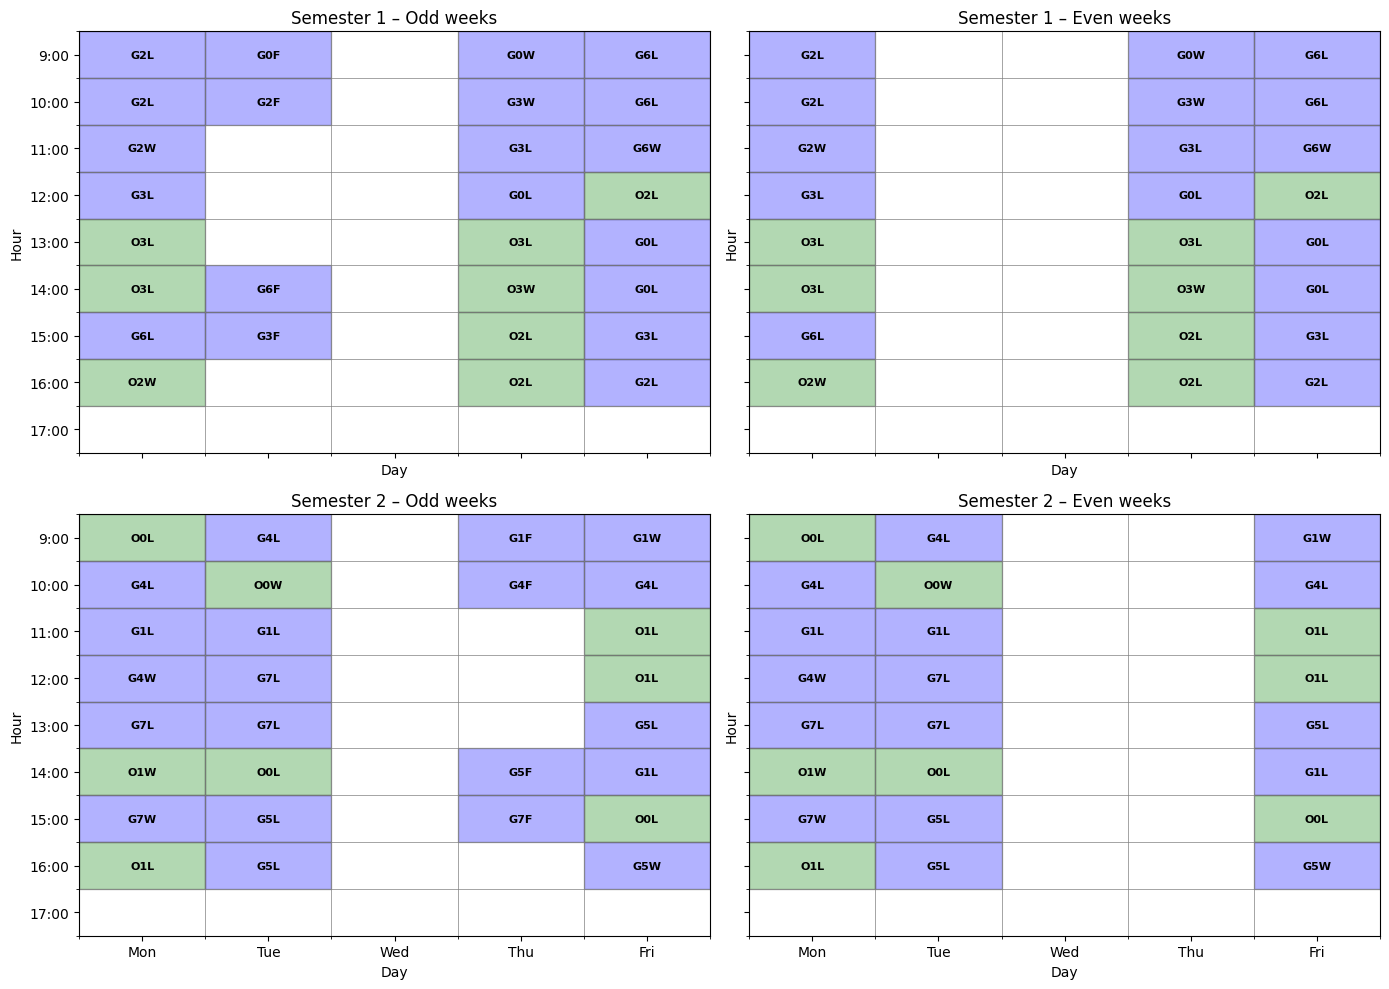

In [25]:
# Retrieve final solution (same as before)
xL_sol2 = {k: m.getSolution(v) for k, v in xL.items()}
xW_sol2 = {k: m.getSolution(v) for k, v in xW.items()}
xF_sol2 = {k: m.getSolution(v) for k, v in xF.items()}
yL_sol2 = {k: m.getSolution(v) for k, v in yL.items()}
yW_sol2 = {k: m.getSolution(v) for k, v in yW.items()}
z_sol2  = {k: m.getSolution(v) for k, v in z.items()}
w_sol2  = {k: m.getSolution(v) for k, v in w.items()}

plot_timetable(xL_sol2,xW_sol2,xF_sol2, yL_sol2, yW_sol2, z_sol2, w_sol2)

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:56: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xL = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:57: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xW = {(g, d, h, s): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:58: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  xF = {(g, d, h, s, w): xp.var(vartype=xp.binary) for g in G for d in D for h in H for s in S for w in W}
C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\2796256781.py:59: DeprecationWarning: Deprecated in Xpress 9.5: create a linked variable by calling problem.addVariable()
  yL = 

FICO Xpress v9.7.0, Hyper, solve started 21:18:12, Mar 22, 2026
Heap usage: 5734KB (peak 5734KB, 4093KB system)
Minimizing MILP noname using up to 8 threads and up to 7975MB memory, with these control settings:
OUTPUTLOG = 1
NLPPOSTSOLVE = 1
XSLP_DELETIONCONTROL = 0
XSLP_OBJSENSE = 1
Original problem has:
      9692 rows         5944 cols        63336 elements      5804 entities
Presolved problem has:
      5888 rows         5752 cols        47450 elements      5552 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 9774KB (peak 14MB, 4093KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  9.00e+00] / [ 1.25e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [ 1.00e+00,  2.00e+00] / [ 1.00e+00,  2.00e+00]
Autoscaling applied standard scaling

Symmetric problem: generators: 16, support set: 5708
 Number of orbits: 

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\1084171910.py:49: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.objval instead
  ideal[obj_name] = m_ideal.getObjVal()


Presolved problem has:
      5888 rows         5752 cols        47450 elements      5552 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 9774KB (peak 14MB, 4095KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  9.00e+00] / [ 1.25e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [ 1.00e+00,  1.00e+00] / [ 1.00e+00,  1.00e+00]
Autoscaling applied standard scaling

Symmetric problem: generators: 16, support set: 5708
 Number of orbits: 390, largest orbit: 32
 Row orbits: 471, row support: 5776
Will try to keep branch and bound tree memory usage below 5.4GB
 *** Solution found:    20.000000   Time:   0.30    Heuristic: e ***
Starting concurrent solve with dual (1 thread) and barrier (7 threads)

              Concurrent-Solve,   0s
            Dual                      Barrier      
    objective   dual inf     

C:\Users\frequensy\AppData\Local\Temp\ipykernel_3108\1084171910.py:66: DeprecationWarning: Deprecated in Xpress 9.5: use problem.attributes.objval instead
  nadir[obj_name] = m_nadir.getObjVal()


Presolved problem has:
      5888 rows         5752 cols        47450 elements      5552 entities
LP relaxation tightened
Presolve finished in 0 seconds
Heap usage: 9774KB (peak 14MB, 4119KB system)

Coefficient range                    original                 solved        
  Coefficients   [min,max] : [ 1.00e+00,  9.00e+00] / [ 1.25e-01,  1.50e+00]
  RHS and bounds [min,max] : [ 1.00e+00,  4.00e+00] / [ 1.00e+00,  4.00e+00]
  Objective      [min,max] : [ 1.00e+00,  1.00e+00] / [ 1.00e+00,  1.00e+00]
Autoscaling applied standard scaling

Symmetric problem: generators: 16, support set: 5708
 Number of orbits: 390, largest orbit: 32
 Row orbits: 471, row support: 5776
Will try to keep branch and bound tree memory usage below 5.4GB
 *** Solution found:    20.000000   Time:   0.30    Heuristic: e ***
STOPPING - MIPRELSTOP target reached (MIPRELSTOP=0.0001  gap=-0).
 *** Search completed ***
Uncrunching matrix
Final MIP objective                   : 2.000000000000000e+01
Final MIP bound  

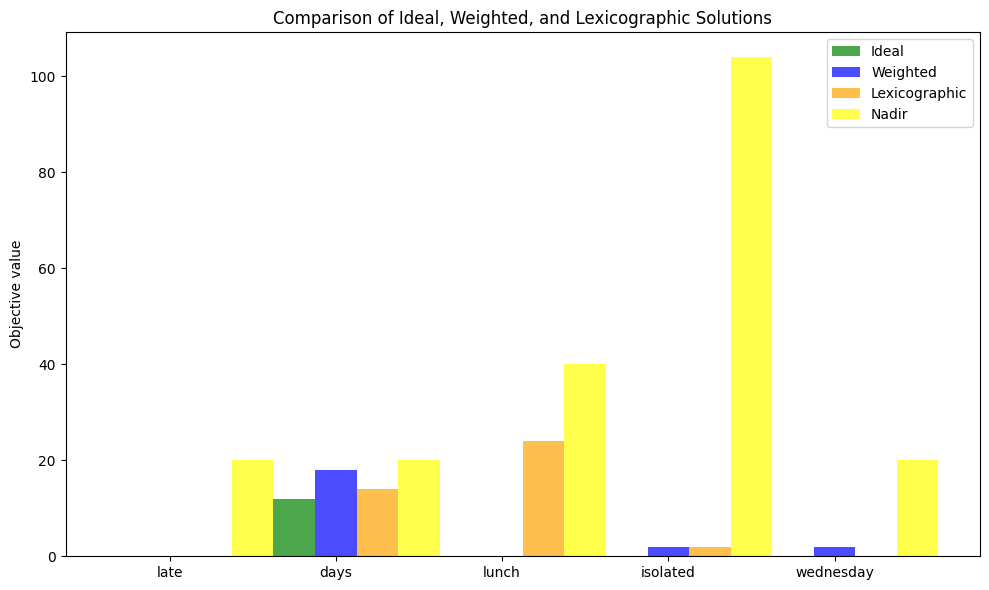

In [31]:
# Helper to compute raw objective values from solution dictionaries
def compute_raw_from_solution(xL_sol, xW_sol, xF_sol, yL_sol, yW_sol, z_sol, w_sol):
    late = lunch = isolated = days = wednesday = 0
    days_set = set()
    for d in D:
        for s in S:
            for w_par in W:
                event = {}
                for h in H:
                    ev = 0
                    for g in G:
                        ev += xL_sol.get((g,d,h,s), 0) + xW_sol.get((g,d,h,s), 0)
                        ev += xF_sol.get((g,d,h,s,w_par), 0)
                    for o in O:
                        ev += yL_sol.get((o,d,h,s), 0) + yW_sol.get((o,d,h,s), 0)
                    event[h] = ev
                late += event.get(8, 0)
                for h in [3,4]:
                    lunch += event.get(h, 0)
                if d == wed_idx:
                    for h in range(4,9):
                        wednesday += event.get(h, 0)
                if any(event[h] > 0 for h in H):
                    days_set.add((d,s,w_par))
                for h in range(1,8):
                    if event.get(h, 0) > 0:
                        left = event.get(h-1, 0) if h>1 else 0
                        right = event.get(h+1, 0) if h<7 else 0
                        if left == 0 and right == 0:
                            isolated += 1
    days = len(days_set)
    return late, lunch, isolated, days, wednesday

# Compute ideal points (as above, but corrected)
ideal = {}
for obj_name in ['late', 'days', 'lunch', 'isolated', 'wednesday']:
    m_ideal, _, _, _, _, _, _, _, _, _, tlate, tlunch, tisol, tdays, twed = build_model()
    if obj_name == 'late':
        m_ideal.setObjective(tlate, sense=xp.minimize)
    elif obj_name == 'days':
        m_ideal.setObjective(tdays, sense=xp.minimize)
    elif obj_name == 'lunch':
        m_ideal.setObjective(tlunch, sense=xp.minimize)
    elif obj_name == 'isolated':
        m_ideal.setObjective(tisol, sense=xp.minimize)
    elif obj_name == 'wednesday':
        m_ideal.setObjective(twed, sense=xp.minimize)
    m_ideal.solve()
    ideal[obj_name] = m_ideal.getObjVal()
    print(f"Ideal {obj_name}: {ideal[obj_name]:.2f}")
# Compute nadir points (maximum possible values)
nadir = {}
for obj_name in ['late', 'days', 'lunch', 'isolated', 'wednesday']:
    m_nadir, _, _, _, _, _, _, _, _, _, tlate, tlunch, tisol, tdays, twed = build_model()
    if obj_name == 'late':
        m_nadir.setObjective(tlate, sense=xp.maximize)
    elif obj_name == 'days':
        m_nadir.setObjective(tdays, sense=xp.maximize)
    elif obj_name == 'lunch':
        m_nadir.setObjective(tlunch, sense=xp.maximize)
    elif obj_name == 'isolated':
        m_nadir.setObjective(tisol, sense=xp.maximize)
    elif obj_name == 'wednesday':
        m_nadir.setObjective(twed, sense=xp.maximize)
    m_nadir.solve()
    nadir[obj_name] = m_nadir.getObjVal()
    print(f"Nadir {obj_name}: {nadir[obj_name]:.2f}")
# Weighted solution raw values (from xL_sol, etc.)
late_w, lunch_w, isolated_w, days_w, wed_w = compute_raw_from_solution(
    xL_sol, xW_sol, xF_sol, yL_sol, yW_sol, z_sol, w_sol)
weighted_raw = {'late': late_w, 'days': days_w, 'lunch': lunch_w,
                'isolated': isolated_w, 'wednesday': wed_w}
print("Weighted raw values:", weighted_raw)

# Lexicographic solution raw values (from xL_sol2, etc.)
late_l, lunch_l, isolated_l, days_l, wed_l = compute_raw_from_solution(
    xL_sol2, xW_sol2, xF_sol2, yL_sol2, yW_sol2, z_sol2, w_sol2)
lex_raw = {'late': late_l, 'days': days_l, 'lunch': lunch_l,
           'isolated': isolated_l, 'wednesday': wed_l}
print("Lexicographic raw values:", lex_raw)

# Comparison table
import pandas as pd
data = []
for obj in ['late', 'days', 'lunch', 'isolated', 'wednesday']:
    ideal_val = ideal[obj]
    nadir_val = nadir[obj]
    w_val = weighted_raw[obj]
    l_val = lex_raw[obj]
    gap_w = (w_val - ideal_val) / (nadir_val - ideal_val) * 100 if (nadir_val - ideal_val) != 0 else 0
    gap_l = (l_val - ideal_val) / (nadir_val - ideal_val) * 100 if (nadir_val - ideal_val) != 0 else 0
    data.append([obj, ideal_val, nadir_val, w_val, l_val, gap_w, gap_l])

df = pd.DataFrame(data, columns=['Objective', 'Ideal', 'Nadir', 'Weighted', 'Lexicographic', 'Gap_W%', 'Gap_L%'])
print("\n" + "="*80)
print("Comparison of Solutions (with Nadir)")
print("="*80)
print(df.to_string(index=False, float_format='%.2f'))
# Bar chart
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(df))
width = 0.25
ax.bar(x - width, df['Ideal'], width, label='Ideal', color='green', alpha=0.7)
ax.bar(x, df['Weighted'], width, label='Weighted', color='blue', alpha=0.7)
ax.bar(x + width, df['Lexicographic'], width, label='Lexicographic', color='orange', alpha=0.7)
ax.bar(x + 2*width, df['Nadir'], width, label='Nadir', color='yellow', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(df['Objective'])
ax.set_ylabel('Objective value')
ax.set_title('Comparison of Ideal, Weighted, and Lexicographic Solutions')
ax.legend()
plt.tight_layout()
plt.show()